# 04 – Model Training
**AlchemiX – Launch26 Phase 2**

## Pipeline at this point
```
[NB02] Raw → Clean → SPLIT (done ✓)
[NB03] Feature Engineering on each split (done ✓)
[NB04] Load pre-split engineered data  ←  YOU ARE HERE
           ↓
       Encode + Scale  (fit on train only)
           ↓
       Benchmark models (cross-validation)
           ↓
       Hyperparameter Tuning
           ↓
       Final fit on train
           ↓
       Evaluate on TRAIN  +  TEST  (both reported)
           ↓
       Save models + preprocessors + metadata
```

## Feature lists used (must match Notebook 03 output exactly)
| Model | Numeric features | Categorical |
|---|---|---|
| Congestion | load_units, load_ratio, load_ratio_sq, load_units_x_ratio, near_capacity, hist_mean_load_ratio, hist_std_load_ratio, hist_mean_load_units | planet_a, planet_b |
| Trust | self_reported_latency_ms, measured_latency_ms, latency_difference, absolute_difference, latency_ratio, percentage_error, hist_mean_trust, hist_std_trust, hist_mean_latency_diff | planet_a, planet_b |
| Targeting | traffic_share, traffic_percentage, high_traffic_share, hist_attack_rate | planet_a, planet_b |

In [1]:
import sys, pathlib, json
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from ml.utils import (
    RANDOM_SEED, MODELS_DIR,
    TRAFFIC_TRAIN_ENG, TRAFFIC_TEST_ENG,
    TELEMETRY_TRAIN_ENG, TELEMETRY_TEST_ENG,
    INCIDENT_TRAIN_ENG, INCIDENT_TEST_ENG,
    CONGESTION_MODEL_FILE, TRUST_MODEL_FILE, TARGETING_MODEL_FILE,
)
from ml.training import (
    regression_candidates,
    classification_candidates,
    benchmark_models,
    tune_model,
    build_preprocessor,
)
from ml.evaluation import regression_metrics, classification_metrics

np.random.seed(RANDOM_SEED)
print('Imports OK ✓')

Imports OK ✓


---
## Step 1 — Load Pre-Split Engineered Data

In [2]:
traf_train = pd.read_csv(TRAFFIC_TRAIN_ENG)
traf_test  = pd.read_csv(TRAFFIC_TEST_ENG)
tele_train = pd.read_csv(TELEMETRY_TRAIN_ENG)
tele_test  = pd.read_csv(TELEMETRY_TEST_ENG)
inc_train  = pd.read_csv(INCIDENT_TRAIN_ENG)
inc_test   = pd.read_csv(INCIDENT_TEST_ENG)

print('Loaded pre-split engineered files:')
for name, tr, te in [
    ('Traffic',   traf_train,  traf_test),
    ('Telemetry', tele_train,  tele_test),
    ('Incident',  inc_train,   inc_test),
]:
    print(f'  {name:10s}  train={len(tr)}  test={len(te)}  columns={len(tr.columns)}')

Loaded pre-split engineered files:
  Traffic     train=4594  test=1149  columns=15
  Telemetry   train=4800  test=1200  columns=14
  Incident    train=4800  test=1200  columns=11


---
## Step 2 — Define Feature Columns & Validate

In [3]:
# ── Feature definitions ───────────────────────────────────────────────────────
TRAFFIC_NUMERIC = [
    'load_units', 'load_ratio', 'load_ratio_sq', 'load_units_x_ratio',
    'near_capacity',
    'hist_mean_load_ratio', 'hist_std_load_ratio', 'hist_mean_load_units',
]
TRAFFIC_CAT = ['planet_a', 'planet_b']
TARGET_T    = 'observed_latency_ms'

TELE_NUMERIC = [
    'self_reported_latency_ms', 'measured_latency_ms',
    'latency_difference', 'absolute_difference',
    'latency_ratio', 'percentage_error',
    'hist_mean_trust', 'hist_std_trust', 'hist_mean_latency_diff',
]
TELE_CAT  = ['planet_a', 'planet_b']
TARGET_TE = 'trust_score'

INC_NUMERIC = ['traffic_share', 'traffic_percentage', 'high_traffic_share', 'hist_attack_rate']
INC_CAT     = ['planet_a', 'planet_b']
TARGET_I    = 'jammed_flag'

# ── Validation: assert every feature column actually exists ───────────────────
def validate_features(name, df, numeric, cat, target):
    missing = [c for c in numeric + cat if c not in df.columns]
    assert not missing, f'{name}: missing columns in data → {missing}'
    assert target not in numeric + cat, f'{name}: target column {target!r} is in features!'
    print(f'  ✓ {name}: {len(numeric)+len(cat)} features present, target={target!r}')

print('Feature validation:')
validate_features('Traffic',   traf_train, TRAFFIC_NUMERIC, TRAFFIC_CAT, TARGET_T)
validate_features('Telemetry', tele_train, TELE_NUMERIC,    TELE_CAT,    TARGET_TE)
validate_features('Incident',  inc_train,  INC_NUMERIC,     INC_CAT,     TARGET_I)
print('All feature columns validated ✓')

Feature validation:
  ✓ Traffic: 10 features present, target='observed_latency_ms'
  ✓ Telemetry: 11 features present, target='trust_score'
  ✓ Incident: 6 features present, target='jammed_flag'
All feature columns validated ✓


---
## ① Congestion Model  —  `observed_latency_ms` (Regression)

In [4]:
# Select features
X_train_t = traf_train[TRAFFIC_NUMERIC + TRAFFIC_CAT]
y_train_t = traf_train[TARGET_T].values
X_test_t  = traf_test[TRAFFIC_NUMERIC + TRAFFIC_CAT]
y_test_t  = traf_test[TARGET_T].values

# Fit preprocessor on TRAIN only → transform both
preprocessor_t = build_preprocessor(TRAFFIC_NUMERIC, TRAFFIC_CAT)
X_train_t_proc = preprocessor_t.fit_transform(X_train_t)
X_test_t_proc  = preprocessor_t.transform(X_test_t)

print(f'X_train: {X_train_t_proc.shape}  X_test: {X_test_t_proc.shape}')

X_train: (4594, 10)  X_test: (1149, 10)


In [5]:
print('─' * 60)
print('Benchmarking Congestion models (5-fold CV on train)...')
print('─' * 60)
from ml.evaluation import print_comparison_table
candidates_t = regression_candidates(RANDOM_SEED)
results_t = benchmark_models(candidates_t, X_train_t_proc, y_train_t, task='regression')
print_comparison_table(results_t)

────────────────────────────────────────────────────────────
Benchmarking Congestion models (5-fold CV on train)...
────────────────────────────────────────────────────────────


15:16:51  INFO      ml.training    RandomForest     cv_mean=-56063.8934  cv_std=30902.2085  time=3.6s
15:16:55  INFO      ml.training    XGBoost          cv_mean=-65838.5893  cv_std=34848.9846  time=3.7s
15:16:58  INFO      ml.training    LightGBM         cv_mean=-58681.8740  cv_std=32294.6744  time=3.3s
15:17:01  INFO      ml.training    DecisionTree     cv_mean=-64986.4091  cv_std=28627.1919  time=2.2s



  MODEL COMPARISON
       model       cv_mean       cv_std  train_time_s
     XGBoost -65838.589264 34848.984638          3.70
DecisionTree -64986.409110 28627.191913          2.24
    LightGBM -58681.873967 32294.674363          3.26
RandomForest -56063.893420 30902.208522          3.55



In [6]:
best_name_t = results_t.iloc[0]['model']
print(f'Best model: {best_name_t}')
congestion_model = tune_model(
    regression_candidates(RANDOM_SEED)[best_name_t],
    best_name_t, X_train_t_proc, y_train_t, task='regression'
)
congestion_model.fit(X_train_t_proc, y_train_t)
print('Tuning complete ✓')

Best model: XGBoost


15:17:08  INFO      ml.training  tune_model [XGBoost]: best score=-58992.3631  params={'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


Tuning complete ✓


In [7]:
y_pred_train_t = congestion_model.predict(X_train_t_proc)
y_pred_test_t  = congestion_model.predict(X_test_t_proc)

m_train = regression_metrics(y_train_t, y_pred_train_t)
m_test  = regression_metrics(y_test_t,  y_pred_test_t)

print('\n🎯 CONGESTION MODEL — Train vs Test Results')
print('═' * 60)
results_cong = pd.DataFrame([{'Split': 'Train', **m_train}, {'Split': 'Test', **m_test}])
results_cong = results_cong.set_index('Split').round(4)
display(results_cong)

# Check for overfitting
r2_gap = m_train['R2'] - m_test['R2']
status = '✓ Generalising well' if r2_gap < 0.05 else '⚠ Possible overfit'
print(f'\nR² gap (train-test): {r2_gap:.4f}  →  {status}')

15:17:08  INFO      ml.evaluation    MAE        = 12924.9258
15:17:08  INFO      ml.evaluation    RMSE       = 37787.1760
15:17:08  INFO      ml.evaluation    R2         = 0.9471
15:17:08  INFO      ml.evaluation    MAPE_%     = 7.5825
15:17:08  INFO      ml.evaluation    MAE        = 13870.0540
15:17:08  INFO      ml.evaluation    RMSE       = 54646.3550
15:17:08  INFO      ml.evaluation    R2         = 0.8917
15:17:08  INFO      ml.evaluation    MAPE_%     = 8.1580



🎯 CONGESTION MODEL — Train vs Test Results
════════════════════════════════════════════════════════════


,MAE,RMSE,R2,MAPE_%
Split,,,,
Train,12924.9258,37787.176,0.9471,7.5825
Test,13870.0540,54646.355,0.8917,8.1580



R² gap (train-test): 0.0554  →  ⚠ Possible overfit


15:17:09  INFO      ml.evaluation    MAE        = 12924.9258
15:17:09  INFO      ml.evaluation    RMSE       = 37787.1760
15:17:09  INFO      ml.evaluation    R2         = 0.9471
15:17:09  INFO      ml.evaluation    MAPE_%     = 7.5825
15:17:09  INFO      ml.evaluation    MAE        = 13870.0540
15:17:09  INFO      ml.evaluation    RMSE       = 54646.3550
15:17:09  INFO      ml.evaluation    R2         = 0.8917
15:17:09  INFO      ml.evaluation    MAPE_%     = 8.1580


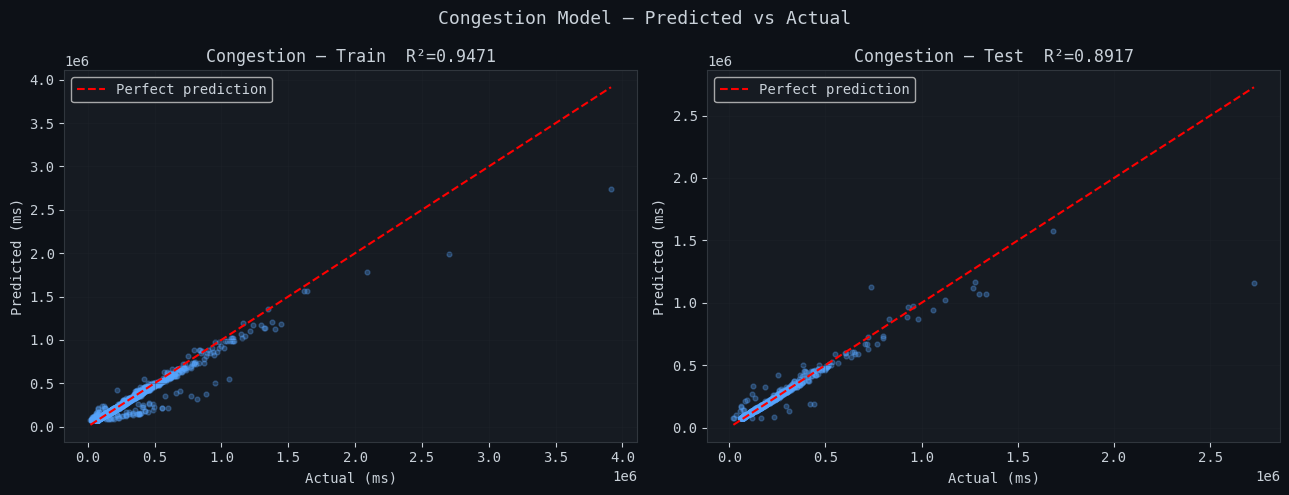

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (split, y_true, y_pred) in zip(axes, [
    ('Train', y_train_t, y_pred_train_t),
    ('Test',  y_test_t,  y_pred_test_t),
]):
    ax.scatter(y_true, y_pred, alpha=0.3, s=12, color='#58a6ff')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual (ms)'); ax.set_ylabel('Predicted (ms)')
    ax.set_title(f'Congestion — {split}  R²={regression_metrics(y_true, y_pred)["R2"]:.4f}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Congestion Model — Predicted vs Actual', fontsize=13)
plt.tight_layout(); plt.show()

---
## ② Trust Model  —  `trust_score` (Regression)

In [9]:
X_train_te = tele_train[TELE_NUMERIC + TELE_CAT]
y_train_te = tele_train[TARGET_TE].values
X_test_te  = tele_test[TELE_NUMERIC + TELE_CAT]
y_test_te  = tele_test[TARGET_TE].values

preprocessor_te = build_preprocessor(TELE_NUMERIC, TELE_CAT)
X_train_te_proc = preprocessor_te.fit_transform(X_train_te)
X_test_te_proc  = preprocessor_te.transform(X_test_te)
print(f'X_train: {X_train_te_proc.shape}  X_test: {X_test_te_proc.shape}')

X_train: (4800, 11)  X_test: (1200, 11)


In [10]:
print('─' * 60)
print('Benchmarking Trust models (5-fold CV on train)...')
print('─' * 60)
candidates_te = regression_candidates(RANDOM_SEED)
results_te = benchmark_models(candidates_te, X_train_te_proc, y_train_te, task='regression')
print_comparison_table(results_te)

────────────────────────────────────────────────────────────
Benchmarking Trust models (5-fold CV on train)...
────────────────────────────────────────────────────────────


15:17:10  INFO      ml.training    RandomForest     cv_mean=-0.0006  cv_std=0.0002  time=0.7s
15:17:10  INFO      ml.training    XGBoost          cv_mean=-0.0013  cv_std=0.0003  time=0.1s
15:17:10  INFO      ml.training    LightGBM         cv_mean=-0.0019  cv_std=0.0005  time=0.6s
15:17:10  INFO      ml.training    DecisionTree     cv_mean=-0.0007  cv_std=0.0001  time=0.1s



  MODEL COMPARISON
       model   cv_mean   cv_std  train_time_s
    LightGBM -0.001860 0.000491          0.60
     XGBoost -0.001298 0.000292          0.07
DecisionTree -0.000717 0.000122          0.14
RandomForest -0.000598 0.000222          0.71



In [11]:
best_name_te = results_te.iloc[0]['model']
print(f'Best model: {best_name_te}')
trust_model = tune_model(
    regression_candidates(RANDOM_SEED)[best_name_te],
    best_name_te, X_train_te_proc, y_train_te, task='regression'
)
trust_model.fit(X_train_te_proc, y_train_te)
print('Tuning complete ✓')

Best model: LightGBM


15:17:49  INFO      ml.training  tune_model [LightGBM]: best score=-0.0015  params={'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 300, 'learning_rate': 0.1}


Tuning complete ✓


In [12]:
y_pred_train_te = np.clip(trust_model.predict(X_train_te_proc), 0, 1)
y_pred_test_te  = np.clip(trust_model.predict(X_test_te_proc),  0, 1)

m_tr_te = regression_metrics(y_train_te, y_pred_train_te)
m_ts_te = regression_metrics(y_test_te,  y_pred_test_te)

print('\n🎯 TRUST MODEL — Train vs Test Results')
print('═' * 60)
results_trust = pd.DataFrame([{'Split': 'Train', **m_tr_te}, {'Split': 'Test', **m_ts_te}])
display(results_trust.set_index('Split').round(4))

r2_gap_te = m_tr_te['R2'] - m_ts_te['R2']
print(f'\nR² gap (train-test): {r2_gap_te:.4f}  →  {"✓ Generalising well" if r2_gap_te < 0.05 else "⚠ Possible overfit"}')

15:17:50  INFO      ml.evaluation    MAE        = 0.0002
15:17:50  INFO      ml.evaluation    RMSE       = 0.0007
15:17:50  INFO      ml.evaluation    R2         = 1.0000
15:17:50  INFO      ml.evaluation    MAPE_%     = 0.0223
15:17:50  INFO      ml.evaluation    MAE        = 0.0003
15:17:50  INFO      ml.evaluation    RMSE       = 0.0009
15:17:50  INFO      ml.evaluation    R2         = 0.9999
15:17:50  INFO      ml.evaluation    MAPE_%     = 0.0363



🎯 TRUST MODEL — Train vs Test Results
════════════════════════════════════════════════════════════


,MAE,RMSE,R2,MAPE_%
Split,,,,
Train,0.0002,0.0007,1.0000,0.0223
Test,0.0003,0.0009,0.9999,0.0363



R² gap (train-test): 0.0000  →  ✓ Generalising well


15:17:50  INFO      ml.evaluation    MAE        = 0.0002
15:17:50  INFO      ml.evaluation    RMSE       = 0.0007
15:17:50  INFO      ml.evaluation    R2         = 1.0000
15:17:50  INFO      ml.evaluation    MAPE_%     = 0.0223
15:17:50  INFO      ml.evaluation    MAE        = 0.0003
15:17:50  INFO      ml.evaluation    RMSE       = 0.0009
15:17:50  INFO      ml.evaluation    R2         = 0.9999


15:17:50  INFO      ml.evaluation    MAPE_%     = 0.0363


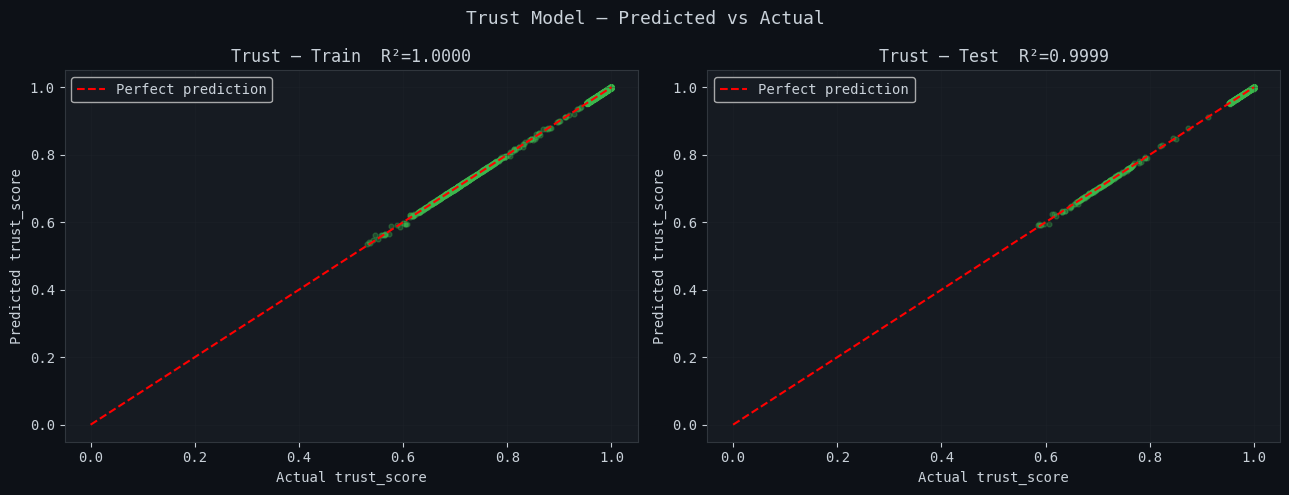

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (split, y_true, y_pred) in zip(axes, [
    ('Train', y_train_te, y_pred_train_te),
    ('Test',  y_test_te,  y_pred_test_te),
]):
    ax.scatter(y_true, y_pred, alpha=0.3, s=12, color='#3fb950')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual trust_score'); ax.set_ylabel('Predicted trust_score')
    ax.set_title(f'Trust — {split}  R²={regression_metrics(y_true, y_pred)["R2"]:.4f}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Trust Model — Predicted vs Actual', fontsize=13)
plt.tight_layout(); plt.show()

---
## ③ Targeting Model  —  `jammed_flag` (Classification)

In [14]:
X_train_i = inc_train[INC_NUMERIC + INC_CAT]
y_train_i = inc_train[TARGET_I].values.astype(int)
X_test_i  = inc_test[INC_NUMERIC + INC_CAT]
y_test_i  = inc_test[TARGET_I].values.astype(int)

preprocessor_i = build_preprocessor(INC_NUMERIC, INC_CAT)
X_train_i_proc = preprocessor_i.fit_transform(X_train_i)
X_test_i_proc  = preprocessor_i.transform(X_test_i)

print(f'X_train: {X_train_i_proc.shape}  X_test: {X_test_i_proc.shape}')
print(f'Train jam rate: {y_train_i.mean():.4f}  Test jam rate: {y_test_i.mean():.4f}')

X_train: (4800, 6)  X_test: (1200, 6)
Train jam rate: 0.0821  Test jam rate: 0.0825


In [15]:
print('─' * 60)
print('Benchmarking Targeting models (5-fold stratified CV on train)...')
print('─' * 60)
candidates_i = classification_candidates(RANDOM_SEED)
results_i = benchmark_models(candidates_i, X_train_i_proc, y_train_i, task='classification')
print_comparison_table(results_i)

────────────────────────────────────────────────────────────
Benchmarking Targeting models (5-fold stratified CV on train)...
────────────────────────────────────────────────────────────


15:17:50  INFO      ml.training    RandomForest     cv_mean=0.5512  cv_std=0.0197  time=0.4s
15:17:51  INFO      ml.training    XGBoost          cv_mean=0.5676  cv_std=0.0250  time=0.1s
15:17:51  INFO      ml.training    LightGBM         cv_mean=0.5603  cv_std=0.0182  time=0.3s
15:17:51  INFO      ml.training    DecisionTree     cv_mean=0.5128  cv_std=0.0222  time=0.1s



  MODEL COMPARISON
       model  cv_mean   cv_std  train_time_s
     XGBoost 0.567613 0.025027          0.07
    LightGBM 0.560257 0.018167          0.35
RandomForest 0.551236 0.019677          0.45
DecisionTree 0.512767 0.022177          0.13



In [16]:
best_name_i = results_i.iloc[-1]['model']  # highest F1
print(f'Best model: {best_name_i}')
targeting_model = tune_model(
    classification_candidates(RANDOM_SEED)[best_name_i],
    best_name_i, X_train_i_proc, y_train_i, task='classification'
)
targeting_model.fit(X_train_i_proc, y_train_i)
print('Tuning complete ✓')

Best model: DecisionTree


15:17:51  INFO      ml.training  tune_model [DecisionTree]: best score=0.5831  params={'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5}


Tuning complete ✓


In [17]:
y_pred_train_i = targeting_model.predict(X_train_i_proc)
y_pred_test_i  = targeting_model.predict(X_test_i_proc)
y_prob_train_i = targeting_model.predict_proba(X_train_i_proc)[:, 1]
y_prob_test_i  = targeting_model.predict_proba(X_test_i_proc)[:, 1]

m_tr_i = classification_metrics(y_train_i, y_pred_train_i, y_prob_train_i)
m_ts_i = classification_metrics(y_test_i,  y_pred_test_i,  y_prob_test_i)

print('\n🎯 TARGETING MODEL — Train vs Test Results')
print('═' * 60)
results_target = pd.DataFrame([{'Split': 'Train', **m_tr_i}, {'Split': 'Test', **m_ts_i}])
display(results_target.set_index('Split').round(4))

f1_gap = m_tr_i['F1'] - m_ts_i['F1']
print(f'\nF1 gap (train-test): {f1_gap:.4f}  →  {"✓ Generalising well" if f1_gap < 0.10 else "⚠ Possible overfit"}')

15:17:51  INFO      ml.evaluation    Accuracy     = 0.7110
15:17:51  INFO      ml.evaluation    Precision    = 0.1491
15:17:51  INFO      ml.evaluation    Recall       = 0.5355
15:17:51  INFO      ml.evaluation    F1           = 0.2333
15:17:51  INFO      ml.evaluation    ROC_AUC      = 0.6700
15:17:51  INFO      ml.evaluation    Accuracy     = 0.7017
15:17:51  INFO      ml.evaluation    Precision    = 0.1289
15:17:51  INFO      ml.evaluation    Recall       = 0.4545
15:17:51  INFO      ml.evaluation    F1           = 0.2009
15:17:51  INFO      ml.evaluation    ROC_AUC      = 0.5837



🎯 TARGETING MODEL — Train vs Test Results
════════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1,ROC_AUC
Split,,,,,
Train,0.7110,0.1491,0.5355,0.2333,0.6700
Test,0.7017,0.1289,0.4545,0.2009,0.5837



F1 gap (train-test): 0.0324  →  ✓ Generalising well


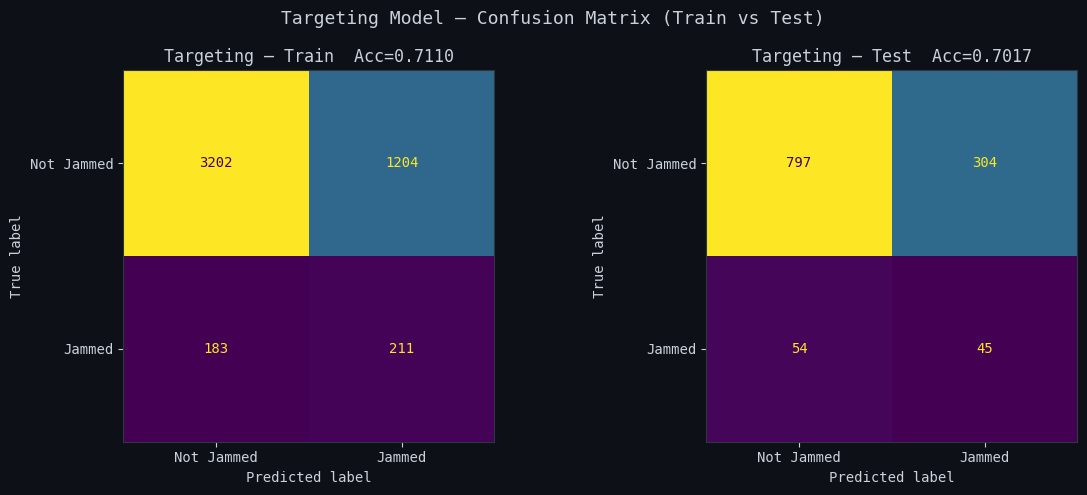

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split, y_true, y_pred) in zip(axes, [
    ('Train', y_train_i, y_pred_train_i),
    ('Test',  y_test_i,  y_pred_test_i),
]):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Jammed', 'Jammed']).plot(ax=ax, colorbar=False)
    acc = (y_true == y_pred).mean()
    ax.set_title(f'Targeting — {split}  Acc={acc:.4f}')
plt.suptitle('Targeting Model — Confusion Matrix (Train vs Test)', fontsize=13)
plt.tight_layout(); plt.show()

---
## Final Summary — All Three Models

In [19]:
print('╔' + '═'*70 + '╗')
print('║  FINAL MODEL RESULTS — AlchemiX Phase 2                            ║')
print('╠' + '═'*70 + '╣')

summary_rows = [
    {'Model': 'Congestion', 'Task': 'Regression',     'Metric': 'R²',
     'Train': round(m_train['R2'], 4),     'Test': round(m_test['R2'], 4),
     'Train MAE': f'{m_train["MAE"]/1000:.2f}s', 'Test MAE': f'{m_test["MAE"]/1000:.2f}s'},

    {'Model': 'Trust',      'Task': 'Regression',     'Metric': 'R²',
     'Train': round(m_tr_te['R2'], 4),    'Test': round(m_ts_te['R2'], 4),
     'Train MAE': f'{m_tr_te["MAE"]:.4f}', 'Test MAE': f'{m_ts_te["MAE"]:.4f}'},

    {'Model': 'Targeting',  'Task': 'Classification', 'Metric': 'F1',
     'Train': round(m_tr_i['F1'], 4),     'Test': round(m_ts_i['F1'], 4),
     'Train MAE': f'Acc={m_tr_i["Accuracy"]:.4f}', 'Test MAE': f'Acc={m_ts_i["Accuracy"]:.4f}'},
]
display(pd.DataFrame(summary_rows).set_index('Model'))

╔══════════════════════════════════════════════════════════════════════╗
║  FINAL MODEL RESULTS — AlchemiX Phase 2                            ║
╠══════════════════════════════════════════════════════════════════════╣


,Task,Metric,Train,Test,Train MAE,Test MAE
Model,,,,,,
Congestion,Regression,R²,0.9471,0.8917,12.92s,13.87s
Trust,Regression,R²,1.0000,0.9999,0.0002,0.0003
Targeting,Classification,F1,0.2333,0.2009,Acc=0.7110,Acc=0.7017


---
## Save Models, Preprocessors & Metadata

In [20]:
joblib.dump(congestion_model, CONGESTION_MODEL_FILE)
joblib.dump(trust_model,      TRUST_MODEL_FILE)
joblib.dump(targeting_model,  TARGETING_MODEL_FILE)
joblib.dump(preprocessor_t,   MODELS_DIR / 'preprocessor_congestion.joblib')
joblib.dump(preprocessor_te,  MODELS_DIR / 'preprocessor_trust.joblib')
joblib.dump(preprocessor_i,   MODELS_DIR / 'preprocessor_targeting.joblib')

# Metadata: feature lists needed by inference_server.py at runtime
meta = {
    'congestion': {
        'numeric': TRAFFIC_NUMERIC, 'categorical': TRAFFIC_CAT, 'target': TARGET_T,
        'train_score': m_train, 'test_score': m_test,
    },
    'trust': {
        'numeric': TELE_NUMERIC, 'categorical': TELE_CAT, 'target': TARGET_TE,
        'train_score': m_tr_te, 'test_score': m_ts_te,
    },
    'targeting': {
        'numeric': INC_NUMERIC, 'categorical': INC_CAT, 'target': TARGET_I,
        'train_score': m_tr_i, 'test_score': m_ts_i,
    },
}
(MODELS_DIR / 'model_metadata.json').write_text(json.dumps(meta, indent=2))

print('Saved:')
for label, f in [
    ('Congestion model',      CONGESTION_MODEL_FILE),
    ('Trust model',           TRUST_MODEL_FILE),
    ('Targeting model',       TARGETING_MODEL_FILE),
    ('Preprocessor congestion', MODELS_DIR / 'preprocessor_congestion.joblib'),
    ('Preprocessor trust',      MODELS_DIR / 'preprocessor_trust.joblib'),
    ('Preprocessor targeting',  MODELS_DIR / 'preprocessor_targeting.joblib'),
    ('Metadata JSON',           MODELS_DIR / 'model_metadata.json'),
]:
    size = pathlib.Path(f).stat().st_size / 1024
    print(f'  {label:<30}  {pathlib.Path(f).name:<45}  {size:7.1f} KB')

print('\n✓ Notebook 04 complete — proceed to Notebook 05 Evaluation.')

Saved:
  Congestion model                congestion.joblib                                724.0 KB
  Trust model                     trust.joblib                                     888.8 KB
  Targeting model                 targeting.joblib                                   5.1 KB
  Preprocessor congestion         preprocessor_congestion.joblib                     3.2 KB
  Preprocessor trust              preprocessor_trust.joblib                          3.3 KB
  Preprocessor targeting          preprocessor_targeting.joblib                      2.9 KB
  Metadata JSON                   model_metadata.json                                2.1 KB

✓ Notebook 04 complete — proceed to Notebook 05 Evaluation.
